# Fund Performance Analytics

This notebook evaluates the performance and risk characteristics of mutual fund schemes using daily NAV data and benchmark indices.

The analysis includes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, and benchmark comparison.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
processed_path = "data/processed"

In [3]:
nav = pd.read_csv(
    os.path.join(processed_path, "02_nav_history_cleaned.csv")
)

benchmark = pd.read_csv(
    os.path.join(processed_path, "10_benchmark_indices.csv")
)

print("NAV shape:", nav.shape)
print("Benchmark shape:", benchmark.shape)

NAV shape: (46000, 3)
Benchmark shape: (8050, 3)


In [4]:
nav.head()
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [5]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [7]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)
print("Missing daily returns:", nav["daily_return"].isna().sum())

Missing daily returns: 40


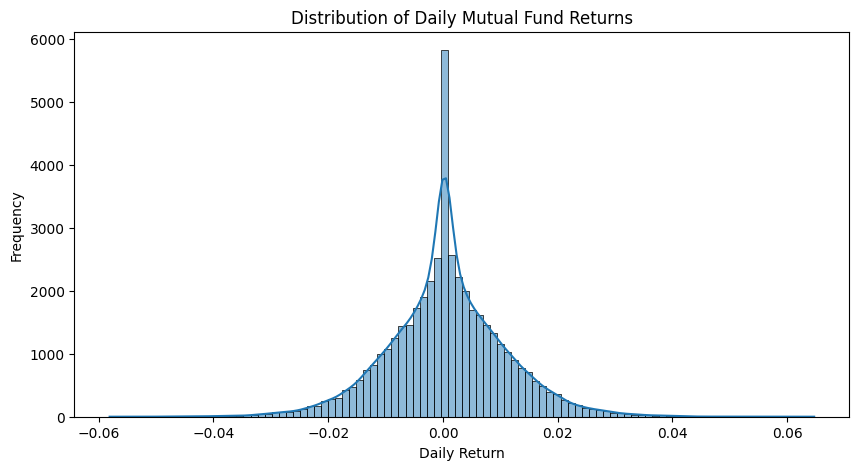

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## 1. Daily Return Analysis

Daily returns were calculated for all 40 mutual fund schemes using the percentage change in NAV from one trading day to the next.

The return distribution was examined to identify unusually large movements and confirm that the daily return values are generally within a reasonable range.

## 2. CAGR Analysis

CAGR (Compound Annual Growth Rate) measures the annualized growth of a mutual fund's NAV over a specified period.

CAGR is calculated for 1-year, 3-year, and 5-year periods to compare long-term fund performance.


In [9]:
print("Start date:", nav["date"].min())
print("End date:", nav["date"].max())

Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00


In [10]:
def calculate_cagr(start_nav, end_nav, years):
    if start_nav <= 0 or end_nav <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1 / years) - 1

In [11]:
cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    end_date = group["date"].max()
    end_nav = group.iloc[-1]["nav"]

    result = {
        "amfi_code": amfi_code,
        "latest_date": end_date,
        "latest_nav": end_nav
    }

    for years in [1, 3, 5]:

        target_date = end_date - pd.DateOffset(years=years)

        previous_data = group[group["date"] <= target_date]

        if len(previous_data) > 0:
            start_nav = previous_data.iloc[-1]["nav"]

            result[f"cagr_{years}yr"] = calculate_cagr(
                start_nav,
                end_nav,
                years
            )
        else:
            result[f"cagr_{years}yr"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,latest_date,latest_nav,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,2026-05-29,583.6113,-0.022243,0.012926,NaN
1,100025,2026-05-29,31.8843,0.037050,0.039164,NaN
2,100033,2026-05-29,342.0072,0.532324,0.324425,NaN
3,101206,2026-05-29,773.2939,0.479241,0.289677,NaN
4,101207,2026-05-29,53.9836,-0.239860,-0.041524,NaN


In [12]:
print("Total funds:", len(cagr_df))

print("\n1-Year CAGR available:",
      cagr_df["cagr_1yr"].notna().sum())

print("3-Year CAGR available:",
      cagr_df["cagr_3yr"].notna().sum())

print("5-Year CAGR available:",
      cagr_df["cagr_5yr"].notna().sum())

Total funds: 40

1-Year CAGR available: 40
3-Year CAGR available: 40
5-Year CAGR available: 0


In [13]:
cagr_comparison = cagr_df[
    [
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
].copy()

cagr_comparison[
    ["cagr_1yr", "cagr_3yr", "cagr_5yr"]
] = (
    cagr_comparison[
        ["cagr_1yr", "cagr_3yr", "cagr_5yr"]
    ] * 100
).round(2)

cagr_comparison.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN
5,101208,7.24,6.32,NaN
6,102885,20.21,19.67,NaN
7,102886,-16.80,-0.77,NaN
8,102887,13.58,25.56,NaN
9,118632,33.98,22.65,NaN


In [14]:
cagr_comparison.describe()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
count,40.000000,40.000000,40.000000,0.0
mean,120247.000000,19.428250,16.415250,NaN
std,14534.998667,22.912863,12.206893,NaN
min,100016.000000,-42.800000,-11.710000,NaN
25%,118632.750000,7.382500,6.605000,NaN
50%,119551.500000,17.475000,18.230000,NaN
75%,120842.250000,27.165000,26.902500,NaN
max,149324.000000,82.780000,35.110000,NaN


In [15]:
cagr_comparison.sort_values(
    "cagr_3yr",
    ascending=False
).head(5)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,22.26,35.11,NaN
34,148567,20.36,34.00,NaN
24,120504,13.06,32.49,NaN
2,100033,53.23,32.44,NaN
25,120505,29.60,31.78,NaN


## 3. Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted return by comparing a fund's excess return over the risk-free rate with its return volatility.

A risk-free rate of 6.5% is used as a proxy based on the RBI repo rate.

In [16]:
risk_free_annual = 0.065
risk_free_daily = (1 + risk_free_annual) ** (1 / 252) - 1

print("Annual risk-free rate:", risk_free_annual)
print("Daily risk-free rate:", risk_free_daily)

Annual risk-free rate: 0.065
Daily risk-free rate: 0.00024993122427763304


In [17]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1 and returns.std() != 0:

        excess_returns = returns - risk_free_daily

        sharpe = (
            excess_returns.mean()
            / returns.std()
        ) * np.sqrt(252)

    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.187650
1,100025,-0.515438
2,100033,1.104352
3,101206,1.041061
4,101207,0.170481


In [18]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,sharpe_rank
0,148567,1.462504,1
1,120843,1.319442,2
2,148569,1.246344,3
3,119551,1.222947,4
4,120505,1.190559,5
5,149323,1.143490,6
6,100033,1.104352,7
7,118632,1.095918,8
8,101206,1.041061,9
9,120504,1.040569,10


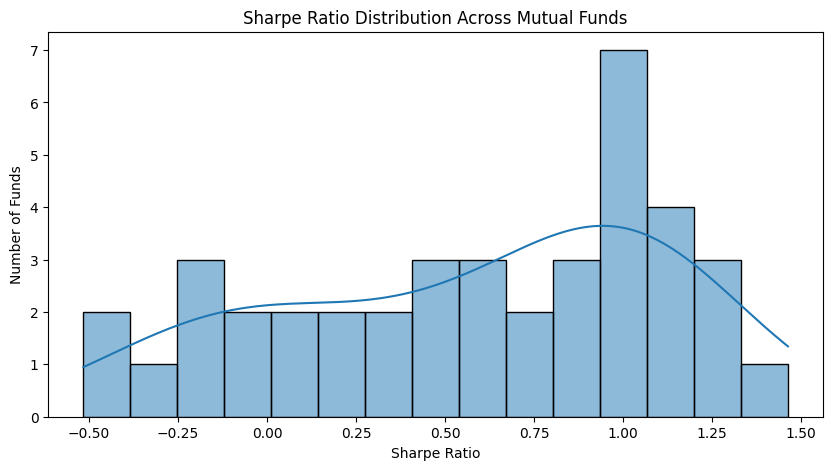

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sharpe_df["sharpe_ratio"].dropna(),
    bins=15,
    kde=True
)

plt.title("Sharpe Ratio Distribution Across Mutual Funds")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.show()

### Key Finding

The Sharpe Ratio comparison highlights which mutual fund schemes generated stronger risk-adjusted returns relative to the assumed 6.5% annual risk-free rate.

In [22]:
sharpe_df.head(10)[
    ["amfi_code", "sharpe_ratio", "sharpe_rank"]
]

,amfi_code,sharpe_ratio,sharpe_rank
0,148567,1.462504,1
1,120843,1.319442,2
2,148569,1.246344,3
3,119551,1.222947,4
4,120505,1.190559,5
5,149323,1.143490,6
6,100033,1.104352,7
7,118632,1.095918,8
8,101206,1.041061,9
9,120504,1.040569,10


## 4. Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted return using only downside volatility. Unlike the Sharpe Ratio, it does not penalize positive return volatility.

The same 6.5% annual risk-free rate is used as the return benchmark.

In [23]:
sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        excess_returns = returns - risk_free_daily

        # Only negative excess returns are considered downside risk
        downside_returns = excess_returns[excess_returns < 0]

        if len(downside_returns) > 1:
            downside_std = downside_returns.std()

            sortino = (
                excess_returns.mean()
                / downside_std
            ) * np.sqrt(252)
        else:
            sortino = np.nan

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.324237
1,100025,-0.833247
2,100033,1.841589
3,101206,1.809663
4,101207,0.287817


In [24]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

sortino_df.head(10)

,amfi_code,sortino_ratio,sortino_rank
0,148567,2.391584,1
1,120843,2.375807,2
2,148569,2.154817,3
3,119551,2.129515,4
4,120505,2.029007,5
5,149323,1.887702,6
6,118632,1.864112,7
7,100033,1.841589,8
8,101206,1.809663,9
9,120504,1.809465,10


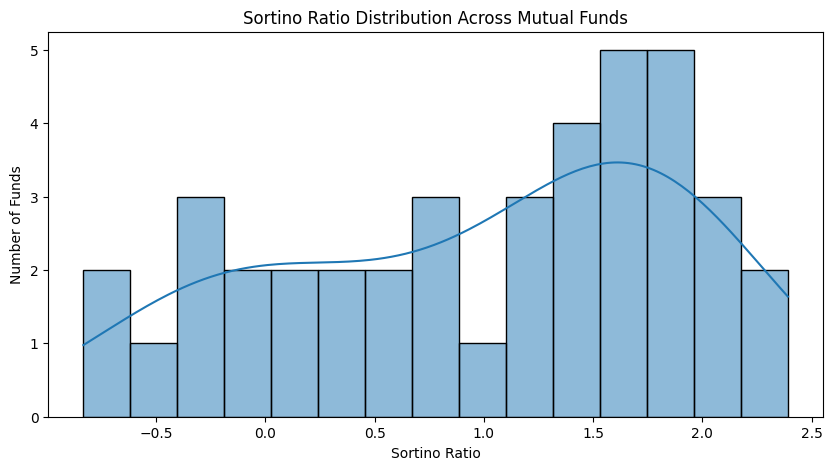

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sortino_df["sortino_ratio"].dropna(),
    bins=15,
    kde=True
)

plt.title("Sortino Ratio Distribution Across Mutual Funds")
plt.xlabel("Sortino Ratio")
plt.ylabel("Number of Funds")

plt.show()

### Key Finding

The Sortino Ratio identifies funds that generated stronger returns relative to their downside risk, with less penalty for normal positive-return volatility.

In [26]:
sortino_df.head(10)[
    ["amfi_code", "sortino_ratio", "sortino_rank"]
]

,amfi_code,sortino_ratio,sortino_rank
0,148567,2.391584,1
1,120843,2.375807,2
2,148569,2.154817,3
3,119551,2.129515,4
4,120505,2.029007,5
5,149323,1.887702,6
6,118632,1.864112,7
7,100033,1.841589,8
8,101206,1.809663,9
9,120504,1.809465,10


## 5. Alpha and Beta Analysis

Alpha measures a mutual fund's performance relative to its benchmark, while Beta measures the fund's sensitivity to movements in the benchmark.

In this analysis, fund daily returns are compared with Nifty 100 daily returns using linear regression.

Alpha is annualized by multiplying the regression intercept by 252 trading days.

In [35]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [36]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [37]:
print("NAV start:", nav["date"].min())
print("NAV end:", nav["date"].max())
print("NAV date type:", nav["date"].dtype)

NAV start: 2022-01-03 00:00:00
NAV end: 2026-05-29 00:00:00
NAV date type: datetime64[us]


In [38]:
print("Benchmark start:", benchmark["date"].min())
print("Benchmark end:", benchmark["date"].max())
print("Benchmark date type:", benchmark["date"].dtype)

Benchmark start: 2022-01-03
Benchmark end: 2026-05-29
Benchmark date type: str


In [39]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print("NIFTY100 rows:", len(nifty100))
nifty100.head()

NIFTY100 rows: 1150


,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [40]:
nifty100["date"] = pd.to_datetime(nifty100["date"])

In [41]:
print("NIFTY100 start:", nifty100["date"].min())
print("NIFTY100 end:", nifty100["date"].max())

NIFTY100 start: 2022-01-03 00:00:00
NIFTY100 end: 2026-05-29 00:00:00


In [42]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [43]:
common_dates = set(nav["date"]).intersection(
    set(nifty100["date"])
)

print("Common dates:", len(common_dates))

Common dates: 1150


In [44]:
test_fund = nav[
    nav["amfi_code"] == nav["amfi_code"].iloc[0]
][["date", "daily_return"]].dropna()

test_merged = test_fund.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
).dropna()

print("Test fund observations:", len(test_merged))
test_merged.head()

Test fund observations: 1149


,date,daily_return,benchmark_return
0,2022-01-04,-0.010306,-0.013540
1,2022-01-05,0.012865,0.004003
2,2022-01-06,-0.011377,-0.002935
3,2022-01-07,-0.001210,0.006150
4,2022-01-10,-0.008639,-0.008351


In [45]:
from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    # Fund daily returns
    fund_returns = group[
        ["date", "daily_return"]
    ].dropna()

    # Match fund returns with NIFTY100 returns
    merged = fund_returns.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 1:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        # Annualized Alpha
        alpha = regression.intercept * 252

    else:
        beta = np.nan
        alpha = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta,
        "observations": len(merged)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,alpha,beta,observations
0,100016,0.037476,-0.058268,1149
1,100025,0.042818,0.001158,1149
2,100033,0.271954,0.005104,1149
3,101206,0.213998,0.021086,1149
4,101207,0.108971,-0.065289,1149


In [46]:
print(alpha_beta_df["observations"].describe())

count      40.0
mean     1149.0
std         0.0
min      1149.0
25%      1149.0
50%      1149.0
75%      1149.0
max      1149.0
Name: observations, dtype: float64


In [47]:
print("Funds:", len(alpha_beta_df))
print("Alpha missing:", alpha_beta_df["alpha"].isna().sum())
print("Beta missing:", alpha_beta_df["beta"].isna().sum())

Funds: 40
Alpha missing: 0
Beta missing: 0


In [48]:
alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,observations,alpha_rank
0,119598,0.303370,-0.023196,1149,1
1,149324,0.300579,0.011455,1149,2
2,120505,0.292636,0.000549,1149,3
3,148569,0.282704,0.018134,1149,4
4,120843,0.273305,-0.022830,1149,5
5,100033,0.271954,0.005104,1149,6
6,148567,0.269838,0.023684,1149,7
7,149323,0.265986,-0.002523,1149,8
8,119094,0.260767,-0.066265,1149,9
9,119551,0.232010,-0.031751,1149,10


In [49]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully.")

alpha_beta.csv saved successfully.


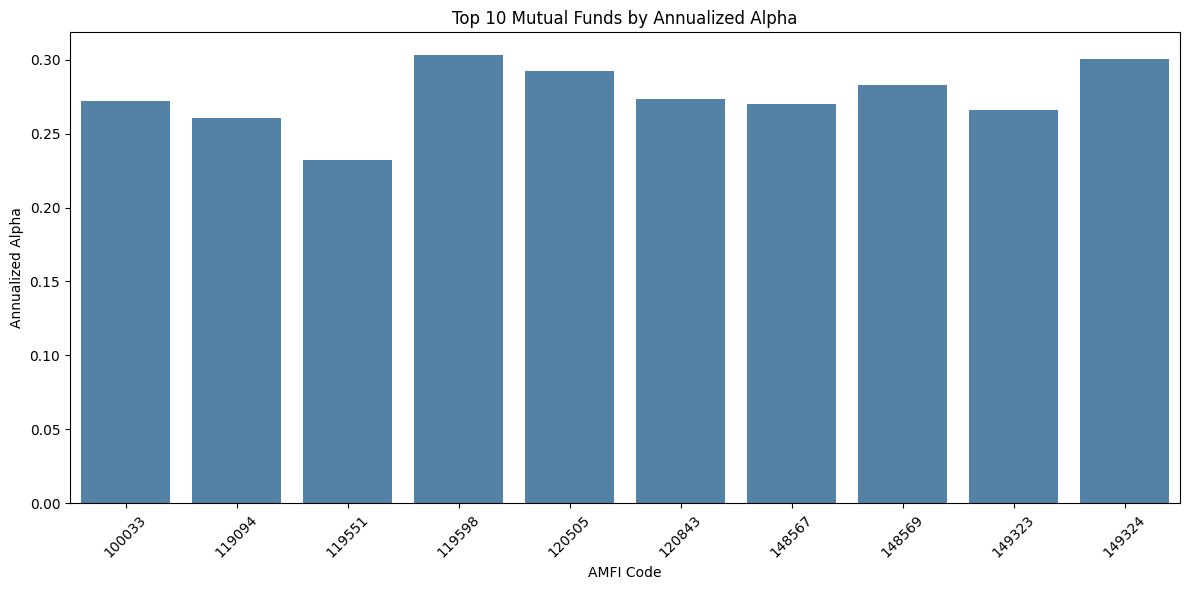

In [50]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=alpha_beta_df.head(10),
    x="amfi_code",
    y="alpha",
    color="steelblue"
)

plt.title("Top 10 Mutual Funds by Annualized Alpha")
plt.xlabel("AMFI Code")
plt.ylabel("Annualized Alpha")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Finding

The Alpha and Beta analysis compares each fund's daily returns with the NIFTY100 benchmark. Positive alpha indicates stronger benchmark-adjusted performance, while beta indicates the fund's sensitivity to movements in the NIFTY100.

## 6. Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline in a fund's NAV from a previous peak to a subsequent trough.

For each mutual fund, the running maximum NAV is calculated and the drawdown is measured as:

Drawdown = NAV / Running Maximum NAV − 1

The analysis identifies the maximum drawdown and the corresponding peak and trough dates.

In [51]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Maximum drawdown
    min_index = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_index, "drawdown"]
    trough_date = group.loc[min_index, "date"]

    # NAV at the trough
    trough_nav = group.loc[min_index, "nav"]

    # Peak before the trough
    peak_data = group.loc[:min_index]

    peak_index = peak_data["nav"].idxmax()

    peak_date = group.loc[peak_index, "date"]
    peak_nav = group.loc[peak_index, "nav"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "peak_date": peak_date,
        "peak_nav": peak_nav,
        "trough_date": trough_date,
        "trough_nav": trough_nav
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,max_drawdown,peak_date,peak_nav,trough_date,trough_nav
0,100016,-0.247344,2022-03-30,546.3002,2022-09-15,411.1759
1,100025,-0.043083,2023-05-23,28.7494,2023-07-28,27.5108
2,100033,-0.162172,2022-03-11,111.6641,2022-05-12,93.5553
3,101206,-0.112916,2023-04-24,370.0026,2023-07-05,328.2234
4,101207,-0.354469,2024-11-21,80.3517,2026-05-11,51.8695


In [52]:
drawdown_df["max_drawdown_pct"] = (
    drawdown_df["max_drawdown"] * 100
).round(2)

drawdown_df.head(10)

,amfi_code,max_drawdown,peak_date,peak_nav,trough_date,trough_nav,max_drawdown_pct
0,100016,-0.247344,2022-03-30,546.3002,2022-09-15,411.1759,-24.73
1,100025,-0.043083,2023-05-23,28.7494,2023-07-28,27.5108,-4.31
2,100033,-0.162172,2022-03-11,111.6641,2022-05-12,93.5553,-16.22
3,101206,-0.112916,2023-04-24,370.0026,2023-07-05,328.2234,-11.29
4,101207,-0.354469,2024-11-21,80.3517,2026-05-11,51.8695,-35.45
5,101208,-0.001622,2023-09-05,346.9958,2023-09-12,346.4328,-0.16
6,102885,-0.108599,2022-02-03,93.7848,2022-03-29,83.5999,-10.86
7,102886,-0.280011,2025-01-07,169.8164,2026-04-27,122.2659,-28.00
8,102887,-0.215398,2022-01-03,191.0721,2022-07-04,149.9155,-21.54
9,118632,-0.174141,2024-01-02,81.9320,2024-07-19,67.6643,-17.41


In [53]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown,peak_date,peak_nav,trough_date,trough_nav,max_drawdown_pct
22,119599,-0.525742,2023-01-17,165.7647,2025-10-28,78.6152,-52.57
17,119095,-0.516778,2025-05-22,106.8214,2026-05-11,51.6185,-51.68
4,101207,-0.354469,2024-11-21,80.3517,2026-05-11,51.8695,-35.45
39,149324,-0.311719,2024-05-03,174.4645,2025-01-03,120.0806,-31.17
21,119598,-0.287060,2024-08-28,225.2452,2025-05-14,160.5863,-28.71
7,102886,-0.280011,2025-01-07,169.8164,2026-04-27,122.2659,-28.00
0,100016,-0.247344,2022-03-30,546.3002,2022-09-15,411.1759,-24.73
29,120842,-0.240035,2023-11-09,80.0837,2024-10-17,60.8608,-24.00
11,118634,-0.233449,2025-04-09,126.7224,2026-02-20,97.1392,-23.34
15,119093,-0.217514,2022-02-24,42.2166,2023-05-22,33.0339,-21.75


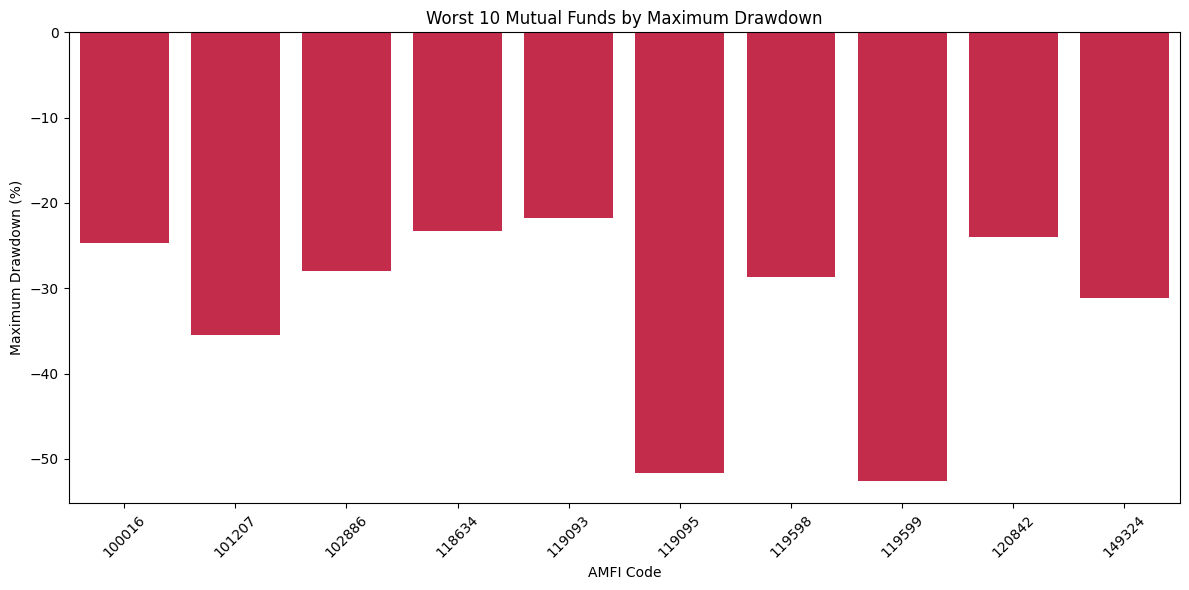

In [54]:
plt.figure(figsize=(12, 6))

worst_10 = drawdown_df.sort_values(
    "max_drawdown_pct"
).head(10)

sns.barplot(
    data=worst_10,
    x="amfi_code",
    y="max_drawdown_pct",
    color="crimson"
)

plt.title("Worst 10 Mutual Funds by Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Finding

Maximum Drawdown identifies the largest peak-to-trough decline experienced by each mutual fund, helping assess the downside risk and severity of historical losses.

In [55]:
drawdown_df.sort_values(
    "max_drawdown"
).head(1)

,amfi_code,max_drawdown,peak_date,peak_nav,trough_date,trough_nav,max_drawdown_pct
22,119599,-0.525742,2023-01-17,165.7647,2025-10-28,78.6152,-52.57


## 7. Fund Scorecard

A composite Fund Scorecard is created to rank the 40 mutual fund schemes on a 0–100 scale.

The score combines long-term return, risk-adjusted performance, benchmark-adjusted performance, cost efficiency, and downside risk.

Weights:
- 30% — 3-Year CAGR
- 25% — Sharpe Ratio
- 20% — Alpha
- 15% — Expense Ratio (inverse rank)
- 10% — Maximum Drawdown (inverse rank)

In [56]:
fund_master = pd.read_csv(
    os.path.join(processed_path, "01_fund_master.csv")
)

fund_master[
    ["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]
].head()

,amfi_code,scheme_name,fund_house,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,0.77


In [57]:
scorecard = cagr_df[
    ["amfi_code", "cagr_3yr"]
].merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code",
    how="left"
).merge(
    alpha_beta_df[
        ["amfi_code", "alpha", "beta"]
    ],
    on="amfi_code",
    how="left"
).merge(
    drawdown_df[
        ["amfi_code", "max_drawdown"]
    ],
    on="amfi_code",
    how="left"
).merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,cagr_3yr,sharpe_ratio,alpha,beta,max_drawdown,scheme_name,fund_house,expense_ratio_pct
0,100016,0.012926,-0.187650,0.037476,-0.058268,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.55
1,100025,0.039164,-0.515438,0.042818,0.001158,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,0.56
2,100033,0.324425,1.104352,0.271954,0.005104,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.38
3,101206,0.289677,1.041061,0.213998,0.021086,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.60
4,101207,-0.041524,0.170481,0.108971,-0.065289,-0.354469,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.53


In [58]:
scorecard["cagr_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False, pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False, pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False, pct=True)
)

# Lower expense ratio = better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, pct=True)
)

# Less negative drawdown = better
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, pct=True)
)

In [59]:
scorecard["fund_score"] = (
    30 * scorecard["cagr_rank"]
    + 25 * scorecard["sharpe_rank"]
    + 20 * scorecard["alpha_rank"]
    + 15 * scorecard["expense_rank"]
    + 10 * scorecard["drawdown_rank"]
)

scorecard["fund_score"] = scorecard["fund_score"].round(2)

In [60]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["overall_rank"] = range(
    1,
    len(scorecard) + 1
)

scorecard[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "cagr_3yr",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
].head(10)

,overall_rank,amfi_code,scheme_name,fund_house,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,-0.007674,-0.194707,0.028969,1.51,-0.280011,88.81
1,2,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,0.012926,-0.187650,0.037476,1.55,-0.247344,88.75
2,3,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-0.117058,-0.067926,0.048016,1.38,-0.516778,85.88
3,4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.041524,0.170481,0.108971,1.53,-0.354469,81.06
4,5,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,0.005259,0.045245,0.068995,1.64,-0.144016,80.56
5,6,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-0.013374,-0.049101,0.048824,0.72,-0.525742,79.19
6,7,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.077560,0.087273,0.078044,1.56,-0.240035,75.50
7,8,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,0.039164,-0.515438,0.042818,0.56,-0.043083,71.25
8,9,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,0.063158,-0.417229,0.060861,0.79,-0.001622,69.00
9,10,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,0.040622,-0.306013,0.050748,0.55,-0.083164,67.88


In [61]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully.")

fund_scorecard.csv saved successfully.


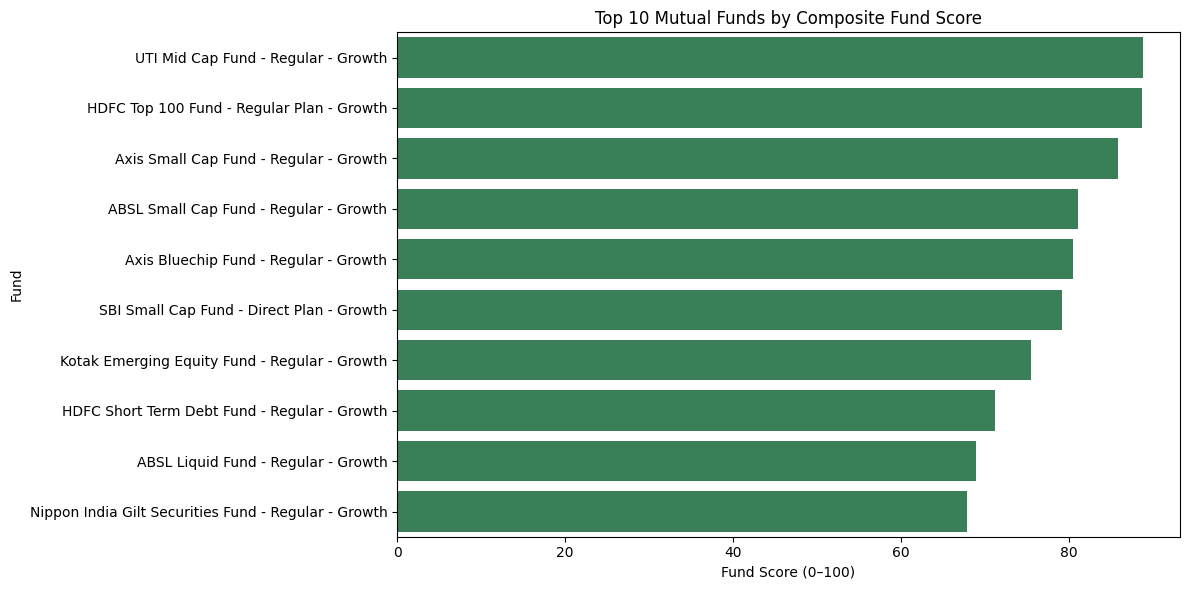

In [62]:
plt.figure(figsize=(12, 6))

top_10 = scorecard.head(10)

sns.barplot(
    data=top_10,
    x="fund_score",
    y="scheme_name",
    color="seagreen"
)

plt.title("Top 10 Mutual Funds by Composite Fund Score")
plt.xlabel("Fund Score (0–100)")
plt.ylabel("Fund")

plt.tight_layout()
plt.show()

### Key Finding

The composite Fund Scorecard ranks mutual funds using a combination of long-term returns, risk-adjusted performance, benchmark-adjusted alpha, expense efficiency, and maximum drawdown.

In [63]:
print(scorecard["fund_score"].min())
print(scorecard["fund_score"].max())
print(scorecard["fund_score"].isna().sum())

16.25
88.81
0


## 8. Benchmark Comparison and Tracking Error

The top five funds from the composite scorecard are compared with the NIFTY50 and NIFTY100 benchmarks over the latest three-year period.

Tracking error measures the volatility of the difference between a fund's daily returns and its benchmark returns.

Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [64]:
top_5_funds = scorecard.head(5)[
    ["amfi_code", "scheme_name", "fund_score"]
].copy()

top_5_funds

,amfi_code,scheme_name,fund_score
0,102886,UTI Mid Cap Fund - Regular - Growth,88.81
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,88.75
2,119095,Axis Small Cap Fund - Regular - Growth,85.88
3,101207,ABSL Small Cap Fund - Regular - Growth,81.06
4,119092,Axis Bluechip Fund - Regular - Growth,80.56


In [65]:
# Prepare benchmark data

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

# Calculate daily returns
nifty50["nifty50_return"] = (
    nifty50["close_value"].pct_change()
)

nifty100["nifty100_return"] = (
    nifty100["close_value"].pct_change()
)

print("NIFTY50 rows:", len(nifty50))
print("NIFTY100 rows:", len(nifty100))

NIFTY50 rows: 1150
NIFTY100 rows: 1150


In [66]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

print("3-year period:")
print("Start:", start_date)
print("End:", latest_date)

3-year period:
Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00


In [67]:
nifty50_3yr = nifty50[
    (nifty50["date"] >= start_date) &
    (nifty50["date"] <= latest_date)
].copy()

nifty100_3yr = nifty100[
    (nifty100["date"] >= start_date) &
    (nifty100["date"] <= latest_date)
].copy()

print("NIFTY50 3-year rows:", len(nifty50_3yr))
print("NIFTY100 3-year rows:", len(nifty100_3yr))

NIFTY50 3-year rows: 785
NIFTY100 3-year rows: 785


In [68]:
benchmark_comparison = pd.DataFrame({
    "date": nifty50_3yr["date"],
    "NIFTY50": nifty50_3yr["close_value"]
})

benchmark_comparison = benchmark_comparison.merge(
    nifty100_3yr[["date", "close_value"]],
    on="date",
    how="inner"
)

benchmark_comparison = benchmark_comparison.rename(
    columns={"close_value": "NIFTY100"}
)

benchmark_comparison.head()

,date,NIFTY50,NIFTY100
0,2023-05-29,24688.69,15324.41
1,2023-05-30,24558.17,15299.69
2,2023-05-31,24476.07,15248.41
3,2023-06-01,24375.89,15139.50
4,2023-06-02,24398.93,15194.66


In [69]:
for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]
    scheme_name = fund["scheme_name"]

    fund_data = nav[
        (nav["amfi_code"] == amfi_code) &
        (nav["date"] >= start_date) &
        (nav["date"] <= latest_date)
    ][["date", "nav"]].copy()

    # Normalize NAV to 100 at the beginning of the period
    fund_data["normalized_nav"] = (
        fund_data["nav"] / fund_data["nav"].iloc[0]
    ) * 100

    benchmark_comparison = benchmark_comparison.merge(
        fund_data[["date", "normalized_nav"]],
        on="date",
        how="left"
    )

    benchmark_comparison = benchmark_comparison.rename(
        columns={"normalized_nav": scheme_name}
    )

benchmark_comparison.head()

,date,NIFTY50,NIFTY100,UTI Mid Cap Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Axis Small Cap Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Regular - Growth
0,2023-05-29,24688.69,15324.41,100.000000,100.000000,100.000000,100.000000,100.000000
1,2023-05-30,24558.17,15299.69,100.558445,100.779857,97.440526,101.713477,97.931861
2,2023-05-31,24476.07,15248.41,101.711210,100.090303,97.556654,100.396359,97.528225
3,2023-06-01,24375.89,15139.50,101.805841,100.630610,98.482734,101.082565,98.194225
4,2023-06-02,24398.93,15194.66,100.577745,100.377472,98.085545,100.394728,98.225597


In [70]:
benchmark_comparison["NIFTY50"] = (
    benchmark_comparison["NIFTY50"]
    / benchmark_comparison["NIFTY50"].iloc[0]
) * 100

benchmark_comparison["NIFTY100"] = (
    benchmark_comparison["NIFTY100"]
    / benchmark_comparison["NIFTY100"].iloc[0]
) * 100

benchmark_comparison.head()

,date,NIFTY50,NIFTY100,UTI Mid Cap Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Axis Small Cap Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Regular - Growth
0,2023-05-29,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2023-05-30,99.471337,99.838689,100.558445,100.779857,97.440526,101.713477,97.931861
2,2023-05-31,99.138796,99.504059,101.711210,100.090303,97.556654,100.396359,97.528225
3,2023-06-01,98.733023,98.793363,101.805841,100.630610,98.482734,101.082565,98.194225
4,2023-06-02,98.826345,99.153312,100.577745,100.377472,98.085545,100.394728,98.225597


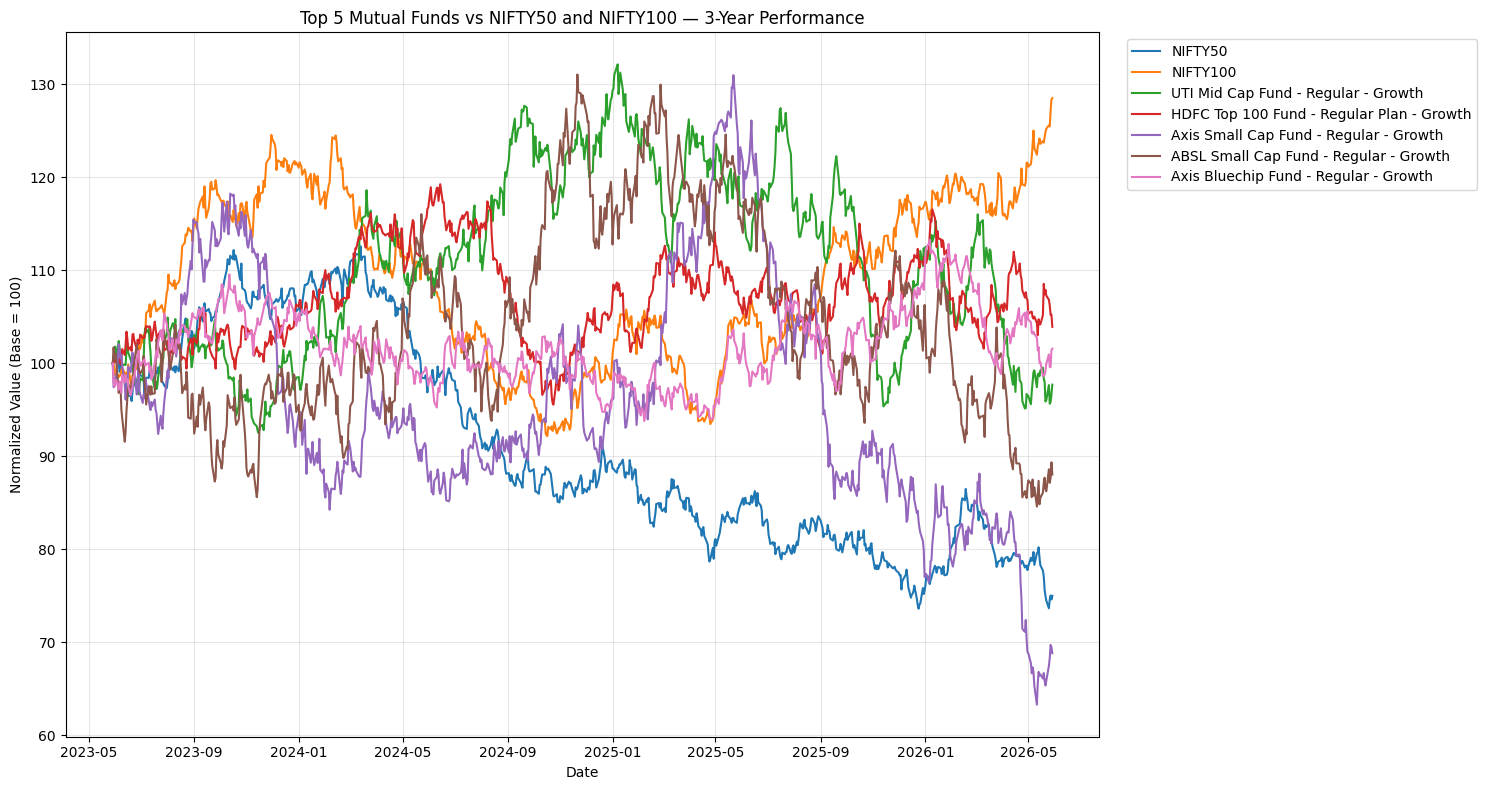

In [71]:
plt.figure(figsize=(15, 8))

for column in benchmark_comparison.columns:
    
    if column != "date":
        plt.plot(
            benchmark_comparison["date"],
            benchmark_comparison[column],
            label=column
        )

plt.title("Top 5 Mutual Funds vs NIFTY50 and NIFTY100 — 3-Year Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
# Recalculate NIFTY100 daily returns
nifty100_3yr = nifty100[
    (nifty100["date"] >= start_date) &
    (nifty100["date"] <= latest_date)
].copy()

nifty100_3yr = nifty100_3yr.sort_values("date")

nifty100_3yr["benchmark_return"] = (
    nifty100_3yr["close_value"].pct_change()
)

print(nifty100_3yr[
    ["date", "close_value", "benchmark_return"]
].head())

           date  close_value  benchmark_return
1515 2023-05-29     15324.41               NaN
1516 2023-05-30     15299.69         -0.001613
1517 2023-05-31     15248.41         -0.003352
1518 2023-06-01     15139.50         -0.007142
1519 2023-06-02     15194.66          0.003643


In [75]:
tracking_error_results = []

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]
    scheme_name = fund["scheme_name"]

    fund_returns = nav[
        (nav["amfi_code"] == amfi_code) &
        (nav["date"] >= start_date) &
        (nav["date"] <= latest_date)
    ][["date", "daily_return"]].dropna()

    merged = fund_returns.merge(
        nifty100_3yr[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "tracking_error": tracking_error,
        "observations": len(merged)
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df

,amfi_code,scheme_name,tracking_error,observations
0,102886,UTI Mid Cap Fund - Regular - Growth,0.223428,784
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.195404,784
2,119095,Axis Small Cap Fund - Regular - Growth,0.283517,784
3,101207,ABSL Small Cap Fund - Regular - Growth,0.293098,784
4,119092,Axis Bluechip Fund - Regular - Growth,0.185936,784


### Key Finding

The benchmark comparison evaluates the five highest-scoring funds against the NIFTY50 and NIFTY100 over the latest three-year period. Tracking error measures how closely each fund's daily returns followed the NIFTY100 benchmark.

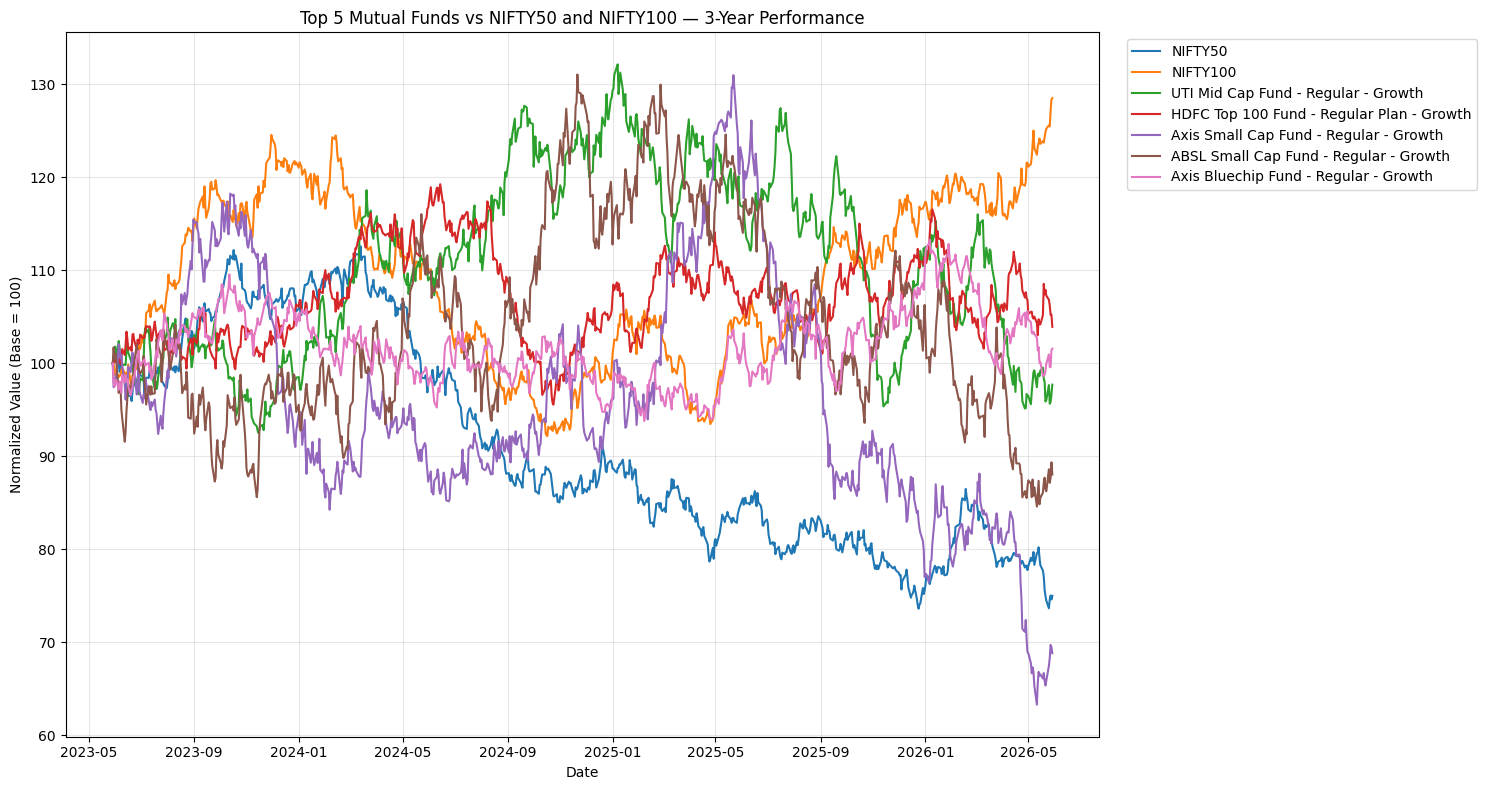

Benchmark comparison PNG saved successfully.


In [76]:
benchmark_comparison.to_csv(
    "benchmark_comparison_data.csv",
    index=False
)

plt.figure(figsize=(15, 8))

for column in benchmark_comparison.columns:
    
    if column != "date":
        plt.plot(
            benchmark_comparison["date"],
            benchmark_comparison[column],
            label=column
        )

plt.title("Top 5 Mutual Funds vs NIFTY50 and NIFTY100 — 3-Year Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "reports/Benchmark_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark comparison PNG saved successfully.")

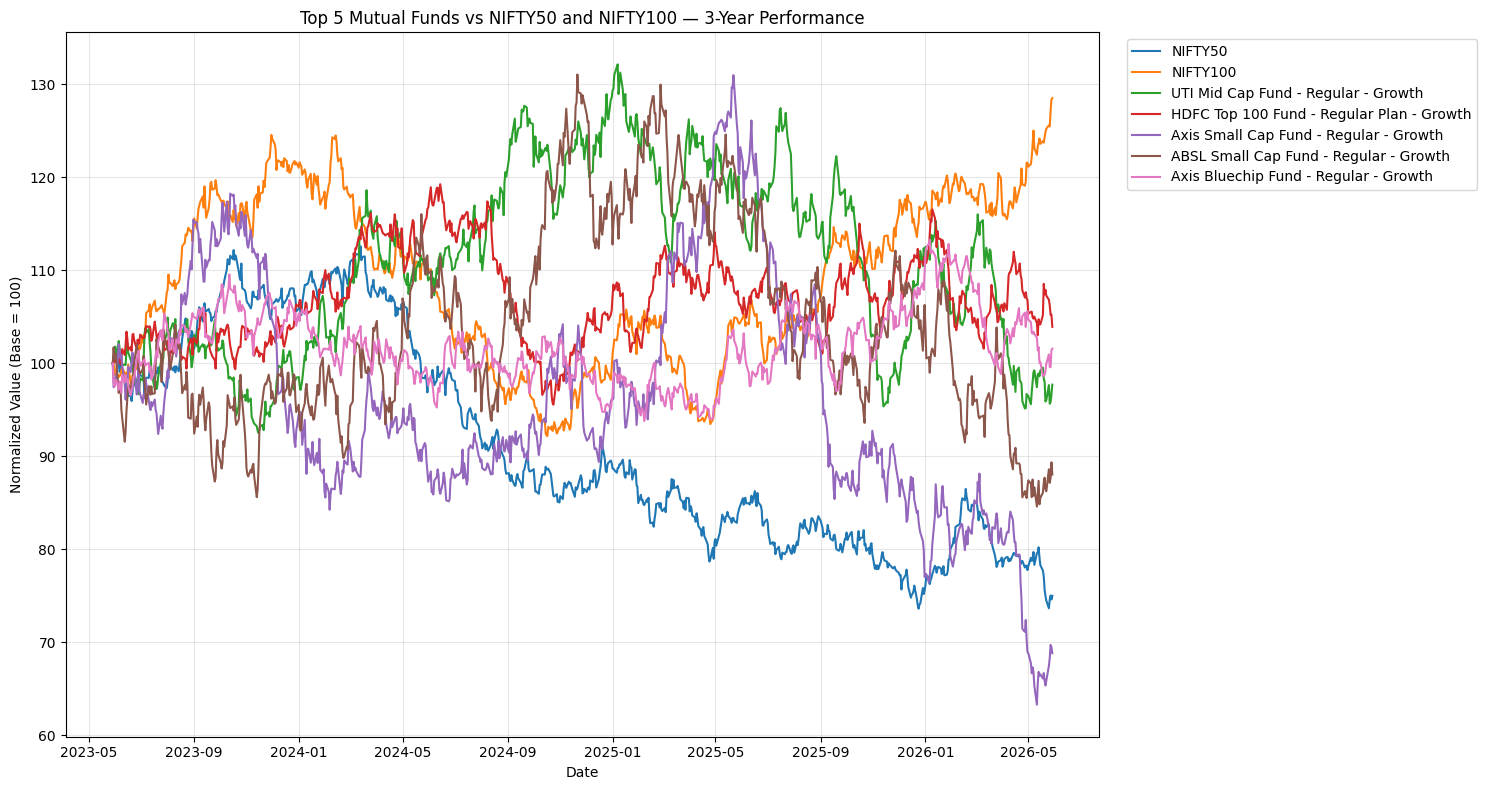

Benchmark_Comparison.png saved successfully.


In [77]:
plt.figure(figsize=(15, 8))

for column in benchmark_comparison.columns:
    if column != "date":
        plt.plot(
            benchmark_comparison["date"],
            benchmark_comparison[column],
            label=column
        )

plt.title(
    "Top 5 Mutual Funds vs NIFTY50 and NIFTY100 — 3-Year Performance"
)
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "reports/Benchmark_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark_Comparison.png saved successfully.")

### Key Finding

The benchmark comparison shows the relative three-year performance of the five highest-scoring mutual funds against the NIFTY50 and NIFTY100. Tracking error indicates the degree to which each fund's returns differ from the NIFTY100 benchmark.

In [79]:
import os

print("fund_scorecard.csv:", os.path.exists("fund_scorecard.csv"))
print("alpha_beta.csv:", os.path.exists("alpha_beta.csv"))
print(
    "Benchmark_Comparison.png:",
    os.path.exists("reports/Benchmark_Comparison.png")
)

fund_scorecard.csv: True
alpha_beta.csv: True
Benchmark_Comparison.png: True
